#LabWeek9: Prevent Overfitting - Part I

## Importing Dataset: IMDB

In [2]:
from keras.datasets import imdb
import numpy as np

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] += 1.  # set specific indices of results[i] to 1s
    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
# Our vectorized labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Note:** We first encountered this dataset in `LabWeek5`. You can refer to that notebook for clarification on the text-to-numbers decoding process. Through vectorizing process we turn text data into vectors.

**Perform some sanity checks on the dataset:** For example, find the `shape` of the dataset and print samples to make sense of the data.

In [3]:
#TODO: your code here


print("train_data shape:", np.shape(train_data))
print("test_data shape:", np.shape(test_data))

print("Number of training samples:", len(train_data))
print("Number of test samples:", len(test_data))

print("First review vectorized input length:", len(train_data[0]))
print("First training label:", train_labels[0])

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("First 10 values of first vectorized sample:")
print(x_train[0][:10])

print("First 5 labels:")
print(train_labels[:5])

train_data shape: (25000,)
test_data shape: (25000,)
Number of training samples: 25000
Number of test samples: 25000
First review vectorized input length: 218
First training label: 1
x_train shape: (25000, 10000)
x_test shape: (25000, 10000)
y_train shape: (25000,)
y_test shape: (25000,)
First 10 values of first vectorized sample:
[ 0.  1.  6.  0. 15.  9.  3.  2.  3.  1.]
First 5 labels:
[1 0 0 1 0]


## Fighting overfitting -  Reducing the network's size


The general workflow to find an appropriate model size is to start with relatively few layers and
parameters, and start increasing the size of the layers or adding new layers until you see diminishing returns with regard to the
validation loss.



**Note:** we use `test set` as our `validation set`.

**Complete the following code for `original model` architecture**

In [13]:
from keras import models
from keras import layers

original_model = models.Sequential()
original_model.add(layers.InputLayer(shape=(10000,)))
original_model.add(layers.Dense(16, activation='relu'))
#TODO: add one hidden layer with 16 units with proper activation function
original_model.add(layers.Dense(16, activation='relu'))


#TODO: add the output layer. Remember our task is binary classificaion, whether a review is 0:negative or 1:positive.
original_model.add(layers.Dense(1, activation='sigmoid'))


original_model.compile(optimizer='rmsprop',
                       loss='binary_crossentropy',
                       metrics=['acc'])

In [ ]:
original_model.summary()

**Define another model with fewer parameters. 4 units in each hidden layer.**

In [15]:
smaller_model = models.Sequential()
#TODO: add hidden/ouput layers and compile the smaller model


smaller_model.add(layers.InputLayer(shape=(10000,)))
smaller_model.add(layers.Dense(4, activation='relu'))
smaller_model.add(layers.Dense(4, activation='relu'))
smaller_model.add(layers.Dense(1, activation='sigmoid'))

smaller_model.compile(optimizer='rmsprop',
                      loss='binary_crossentropy',
                      metrics=['acc'])


**Train (1) original_model and (2) smaller_model seperately for `epochs=20` and `batch_size=512`. Also pass `x_test` and `y_test` as `validation_data`.**

In [14]:
#TODO: your code here for training original_model
original_hist = original_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - acc: 0.7788 - loss: 0.5004 - val_acc: 0.8516 - val_loss: 0.3951
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.8925 - loss: 0.3093 - val_acc: 0.8681 - val_loss: 0.3436
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - acc: 0.9133 - loss: 0.2449 - val_acc: 0.8876 - val_loss: 0.2911
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - acc: 0.9284 - loss: 0.2071 - val_acc: 0.8693 - val_loss: 0.3455
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - acc: 0.9381 - loss: 0.1827 - val_acc: 0.8820 - val_loss: 0.3087
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - acc: 0.9457 - loss: 0.1562 - val_acc: 0.8810 - val_loss: 0.3158
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - acc: 0.9523 - loss: 0.1409 - val_acc: 0.8777 - val_loss: 0.3269
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.9589 - loss: 0.1242 - val_acc: 0.8594 - val_loss: 0.4112
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.9612

In [16]:
#TODO: your code here for training original_model
smaller_hist = smaller_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - acc: 0.6680 - loss: 0.6097 - val_acc: 0.8275 - val_loss: 0.5425
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - acc: 0.8440 - loss: 0.4962 - val_acc: 0.8154 - val_loss: 0.4925
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - acc: 0.8931 - loss: 0.4421 - val_acc: 0.8520 - val_loss: 0.4616
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - acc: 0.9144 - loss: 0.4049 - val_acc: 0.8772 - val_loss: 0.4352
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - acc: 0.9290 - loss: 0.3725 - val_acc: 0.8706 - val_loss: 0.4308
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - acc: 0.9386 - loss: 0.3451 - val_acc: 0.8762 - val_loss: 0.4162
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - acc: 0.9464 - loss: 0.3186 - val_acc: 0.8788 - val_loss: 0.4027
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - acc: 0.9532 - loss: 0.2950 - val_acc: 0.8779 - val_loss: 0.3911
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - acc: 0.9586

**`orginal_hist` and `smaller_hist` are `objects` returned after training the models.**
- We can get access to the `history` attribute of `origial_hist` object through dot operator.
- TODO: The history attribute is a data structure of type `dictionary` containing data about everything that happened during training. Show the `keys` of this `dictionary`.

In [17]:
print(original_hist.history)
#TODO: print out the keys of the output dictionary
#your code here
print(original_hist.history.keys())

{'acc': [0.7788400053977966, 0.8924800157546997, 0.9132800102233887, 0.9284399747848511, 0.9380800127983093, 0.9456800222396851, 0.9523199796676636, 0.9588800072669983, 0.9612399935722351, 0.9655600190162659, 0.974399983882904, 0.9738399982452393, 0.9810400009155273, 0.9839199781417847, 0.9855999946594238, 0.9841200113296509, 0.9905200004577637, 0.9918000102043152, 0.9925600290298462, 0.9903200268745422], 'loss': [0.5003876686096191, 0.30931356549263, 0.2449101358652115, 0.20708909630775452, 0.18266503512859344, 0.15619732439517975, 0.14086340367794037, 0.12422957271337509, 0.11460321396589279, 0.1045982837677002, 0.08394888788461685, 0.08364085108041763, 0.06616439670324326, 0.058336444199085236, 0.05357680097222328, 0.052262526005506516, 0.039168354123830795, 0.03549490123987198, 0.03266403079032898, 0.03561737388372421], 'val_acc': [0.851639986038208, 0.8680800199508667, 0.8876399993896484, 0.8692799806594849, 0.8820400238037109, 0.8809599876403809, 0.8776800036430359, 0.85939997434

**Plot `val_loss` vs. epochs for both models in one plot**

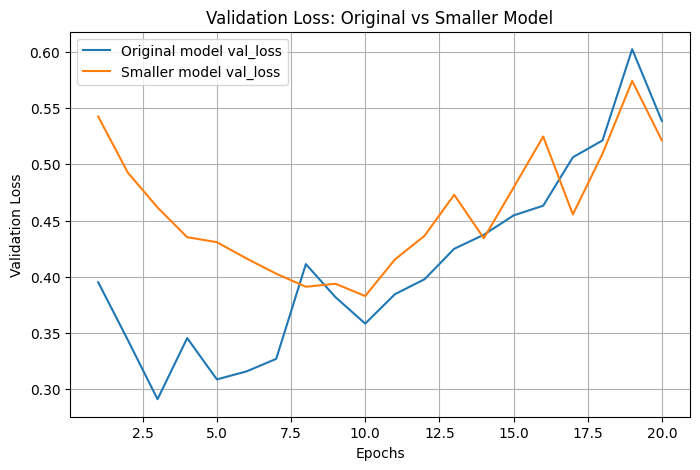

In [18]:
from matplotlib import pyplot as plt
#TODO: your code here

original_val_loss = original_hist.history['val_loss']
smaller_val_loss = smaller_hist.history['val_loss']

epochs = range(1, len(original_val_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, original_val_loss, label='Original model val_loss')
plt.plot(epochs, smaller_val_loss, label='Smaller model val_loss')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Validation Loss: Original vs Smaller Model')
plt.legend()
plt.grid(True)
plt.show()

**Plot training `loss` vs. epochs for both models in one plot**

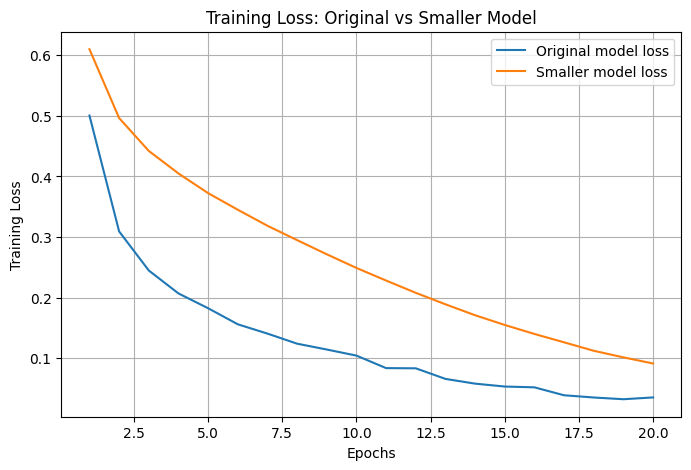

In [19]:
#TODO: your code here

original_loss = original_hist.history['loss']
smaller_loss = smaller_hist.history['loss']

epochs = range(1, len(original_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, original_loss, label='Original model loss')
plt.plot(epochs, smaller_loss, label='Smaller model loss')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Training Loss: Original vs Smaller Model')
plt.legend()
plt.grid(True)
plt.show()

### **Questions:**  Which model overfits earlier? How can you see the size of the model on overfitting?

**Answer:**

### 🔎 Observation

The **original model** starts overfitting earlier than the **smaller model**.

---

### ⚙️ Why does this happen?

The original model has **more parameters**, which means it has **higher model capacity**.  
Because of this, it can **memorize the training data more easily**.

Models with higher capacity usually fit the training data faster, but this also increases the risk of **overfitting**.

---

### 📈 How can we detect overfitting?

Overfitting becomes visible in the training curves when:

- the **training loss continues to decrease**
- but the **validation loss starts increasing**

This means the model is learning the training data too well and is no longer **generalizing to unseen data**.

---

### ✅ Key takeaway

- **Smaller model → overfits more slowly**
- **Larger model → overfits earlier**

**Now define a very large model (e.g., with 512 units in hidden layer) and compare the `loss` and `val_loss` of this big model and the `original model` and `smaller_model`.**

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 405ms/step - acc: 0.7421 - loss: 0.6029 - val_acc: 0.6867 - val_loss: 0.6682
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 475ms/step - acc: 0.8644 - loss: 0.3382 - val_acc: 0.8646 - val_loss: 0.3344
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 447ms/step - acc: 0.8974 - loss: 0.2536 - val_acc: 0.8582 - val_loss: 0.3397
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 329ms/step - acc: 0.9172 - loss: 0.2094 - val_acc: 0.8782 - val_loss: 0.2961
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 337ms/step - acc: 0.9344 - loss: 0.1708 - val_acc: 0.8782 - val_loss: 0.3212
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 331ms/step - acc: 0.9519 - loss: 0.1305 - val_acc: 0.8876 - val_loss: 0.3125
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 353ms/step - acc: 0.9613 - loss: 0.1135 - val_acc: 0.8850 - val_loss: 0.3273
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 334ms/step - acc: 0.9733 - loss: 0.0845 - val_acc: 0.8848 - val_loss: 0.3294
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 324ms/

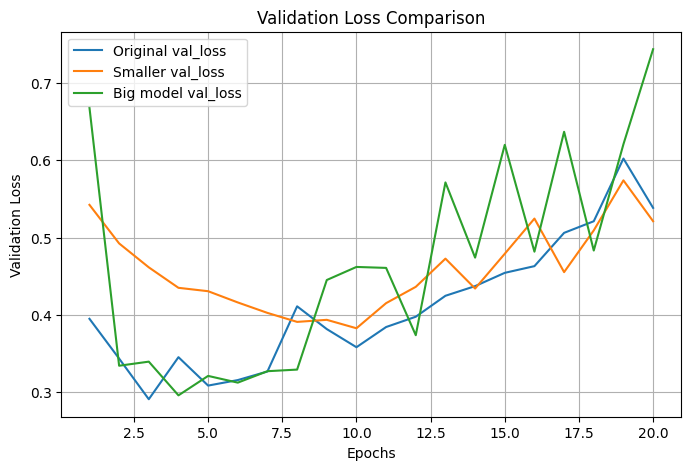

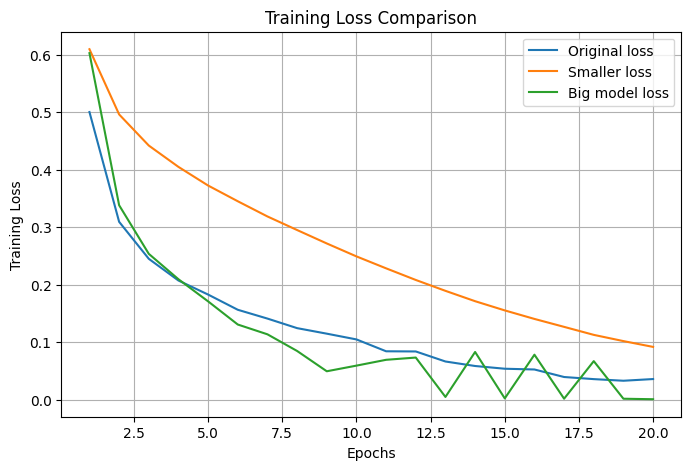

In [20]:
#your code here


big_model = models.Sequential()
big_model.add(layers.InputLayer(shape=(10000,)))
big_model.add(layers.Dense(512, activation='relu'))
big_model.add(layers.Dense(512, activation='relu'))
big_model.add(layers.Dense(1, activation='sigmoid'))

big_model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['acc'])

big_hist = big_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

big_val_loss = big_hist.history['val_loss']
big_loss = big_hist.history['loss']
original_val_loss = original_hist.history['val_loss']
smaller_val_loss = smaller_hist.history['val_loss']
original_loss = original_hist.history['loss']
smaller_loss = smaller_hist.history['loss']

epochs = range(1, len(big_val_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, original_val_loss, label='Original val_loss')
plt.plot(epochs, smaller_val_loss, label='Smaller val_loss')
plt.plot(epochs, big_val_loss, label='Big model val_loss')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, original_loss, label='Original loss')
plt.plot(epochs, smaller_loss, label='Smaller loss')
plt.plot(epochs, big_loss, label='Big model loss')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)
plt.show()

## Discuss the results

**Answer:**

## Model Size and Overfitting

### 🔎 Observation

The **big model** overfits the fastest.

This is expected because it has the **largest number of parameters** and therefore the **highest model capacity**.

---

### 📈 Evidence from the graphs

From the training curves we observe:

- the **training loss decreases very quickly**
- the **validation loss starts increasing earlier**

This indicates that the model begins **memorizing the training data** instead of learning general patterns.

---

### ⚖️ Model comparison

**Big model**

- learns the training data very quickly  
- overfits the earliest  

**Original model**

- performs somewhere in between  
- learns faster than the smaller model  
- begins overfitting earlier  

**Smaller model**

- learns more slowly  
- generalizes better for a longer time  

---

### 🧠 Conclusion

Increasing the size of a model helps it fit the training data better.  
However, larger models also have a **higher risk of overfitting**.

## Fighting overfitting - Adding weight regularization


A common way to mitigate overfitting is to put constraints on the complexity
of a network by forcing its weights to only take small values. This is called
"weight regularization", and it is done by adding to the loss function of the network a _cost_ associated with having large weights. This
cost comes in two flavors:

* L1 regularization, where the cost added is proportional to the _absolute value of the weights coefficients_ (i.e. to what is called the
"L1 norm" of the weights).
* L2 regularization, where the cost added is proportional to the _square of the value of the weights coefficients_ (i.e. to what is called
the "L2 norm" of the weights). L2 regularization is also called _weight decay_ in the context of neural networks. Don't let the different
name confuse you: weight decay is mathematically the exact same as L2 regularization.

In Keras, weight regularization is added by passing _weight regularizer instances_ to layers as keyword arguments.


**Complere the model below**

In [27]:
from keras import regularizers

l2_model = models.Sequential()
l2_model.add(layers.InputLayer(shape=(10000,)))
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),
                          activation='relu'))

#TODO: Add a dense layer with 16 unuts with L2 regularization

l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),activation='relu'))
l2_model.add(layers.Dense(1, activation='sigmoid'))

In [28]:
l2_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['acc'])

`l2(0.001)` means that every coefficient in the weight matrix of the layer will add `0.001 * weight_coefficient_value` to the total loss of
the network. Note that because this penalty is _only added at training time_, the loss for this network will be much higher at training
than at test time.



**Train the model with regularization and compare the validation loss between this model and the `original_model` and `smaller model`.**

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - acc: 0.7741 - loss: 0.5614 - val_acc: 0.8716 - val_loss: 0.4258
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - acc: 0.8886 - loss: 0.3680 - val_acc: 0.8867 - val_loss: 0.3551
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - acc: 0.9060 - loss: 0.3110 - val_acc: 0.8885 - val_loss: 0.3385
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - acc: 0.9166 - loss: 0.2808 - val_acc: 0.8892 - val_loss: 0.3333
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.9225 - loss: 0.2657 - val_acc: 0.8882 - val_loss: 0.3349
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.9275 - loss: 0.2536 - val_acc: 0.8852 - val_loss: 0.3467
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - acc: 0.9301 - loss: 0.2484 - val_acc: 0.8856 - val_loss: 0.3445
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - acc: 0.9323 - loss: 0.2416 - val_acc: 0.8538 - val_loss: 0.4328
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - acc: 0.937

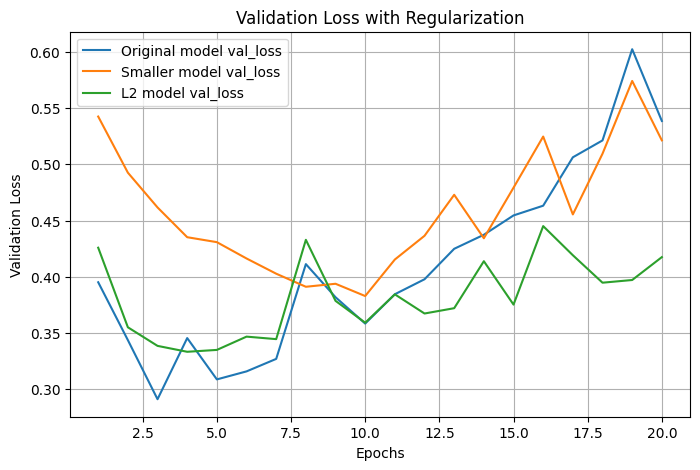

In [29]:
#TODO: your code here

l2_hist = l2_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

l2_val_loss = l2_hist.history['val_loss']
original_val_loss = original_hist.history['val_loss']
smaller_val_loss = smaller_hist.history['val_loss']

epochs = range(1, len(l2_val_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, original_val_loss, label='Original model val_loss')
plt.plot(epochs, smaller_val_loss, label='Smaller model val_loss')
plt.plot(epochs, l2_val_loss, label='L2 model val_loss')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Validation Loss with Regularization')
plt.legend()
plt.grid(True)
plt.show()

**Note:** As alternatives to L2 regularization, you could use one of the following Keras weight regularizers:

In [ ]:
from keras import regularizers

# L1 regularization
regularizers.l1(0.001)

# L1 and L2 regularization at the same time
regularizers.l1_l2(l1=0.001, l2=0.001)

## Recap

To recap: here the most common ways to prevent overfitting in neural networks:

* Getting more training data.
* Reducing the capacity of the network.
* Adding weight regularization.
* Adding dropout. (next session)

**Observation 1:** The bigger network gets its training loss near zero very quickly. The more capacity the network has, the quicker it will be
able to model the training data (resulting in a low training loss), but the more susceptible it is to overfitting (resulting in a large
difference between the training and validation loss).

**Observation 2:** The model with L2 regularization has become much more resistant to overfitting than the reference model,
even though both models have the same number of parameters.